In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hull-tactical-market-prediction/train.csv
/kaggle/input/hull-tactical-market-prediction/test.csv
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_inference_server.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/templates.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/base_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/relay.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/kaggle_evaluation.proto
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2_grpc.py
/kaggl

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.optimize import minimize_scalar  # For tuning
from scipy.optimize import fmin_l_bfgs_b  # For GARCH optimization
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# Constants from adjusted_sharpe
EPS = 1e-9
ANNUAL_DAYS = 252
MAX_POSITION = 1.0  # Assuming from context
MIN_POSITION = -1.0

# Step 1: Load the data
df_train = pd.read_csv('/kaggle/input/hull-tactical-market-prediction/train.csv')
df_test = pd.read_csv('/kaggle/input/hull-tactical-market-prediction/test.csv')

# Combine for common processing if needed, but handle separately
df = df_train.copy()  # Focus on train
df_train.shape

(9021, 98)

In [3]:
# Step 2: Handle Null Values
null_counts = df.isnull().sum()
print("Null Counts:\n", null_counts[null_counts > 0])
df = df.dropna()
print(f"Shape after dropping nulls: {df.shape}")

test_nulls = df_test.isnull().sum()
print("Test Null Counts:\n", test_nulls[test_nulls > 0])
df_test = df_test.dropna()

Null Counts:
 E1     1784
E10    1006
E11    1006
E12    1006
E13    1006
       ... 
V5     1512
V6     1006
V7     1511
V8     1006
V9     4539
Length: 85, dtype: int64
Shape after dropping nulls: (2052, 98)
Test Null Counts:
 Series([], dtype: int64)


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9020
Data columns (total 98 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date_id                        9021 non-null   int64  
 1   D1                             9021 non-null   int64  
 2   D2                             9021 non-null   int64  
 3   D3                             9021 non-null   int64  
 4   D4                             9021 non-null   int64  
 5   D5                             9021 non-null   int64  
 6   D6                             9021 non-null   int64  
 7   D7                             9021 non-null   int64  
 8   D8                             9021 non-null   int64  
 9   D9                             9021 non-null   int64  
 10  E1                             7237 non-null   float64
 11  E10                            8015 non-null   float64
 12  E11                            8015 non-null   f

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

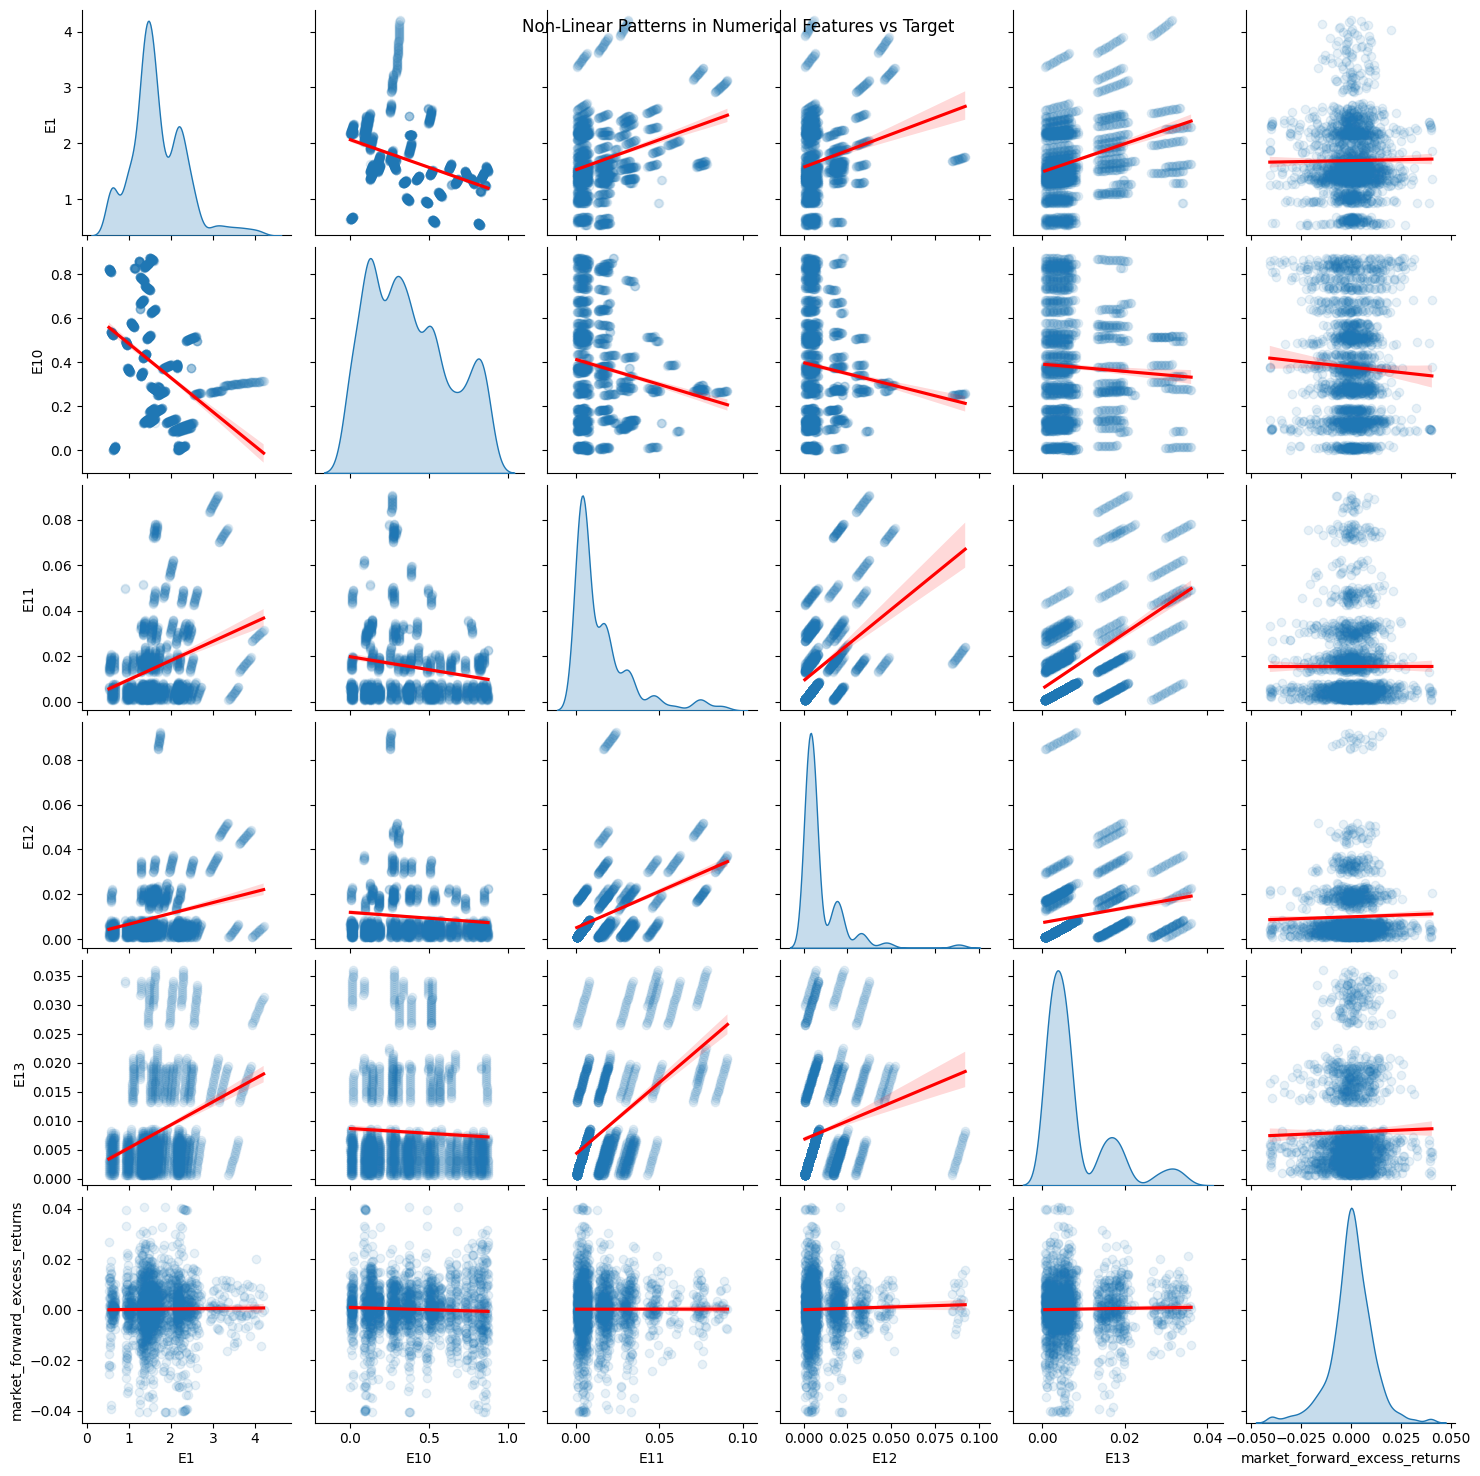

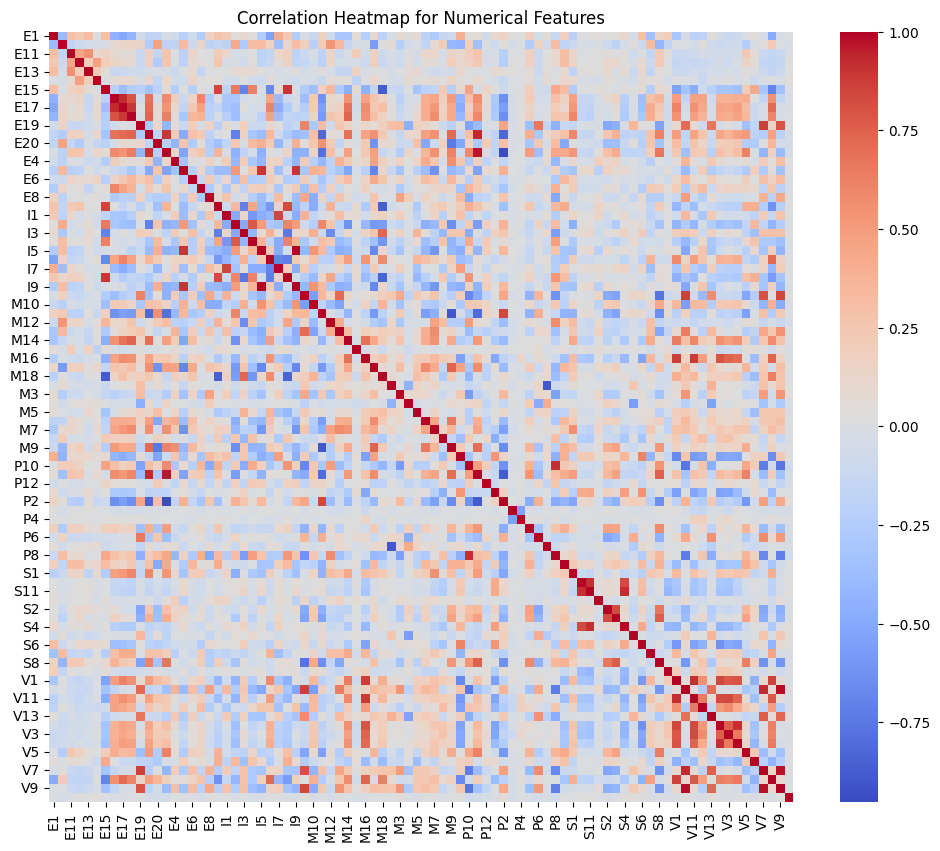

Chi-Squared Tests:
    Cat1 Cat2         Chi2        p-value
0    D1   D2  2019.038745   0.000000e+00
1    D1   D3     0.000000   1.000000e+00
2    D1   D4     0.299227   5.843677e-01
3    D1   D5     0.539605   4.625963e-01
4    D1   D6     0.272565   6.016166e-01
5    D1   D7     2.215833   1.366013e-01
6    D1   D8     2.463925   1.164874e-01
7    D1   D9     0.936395   3.332068e-01
8    D2   D3     0.000000   1.000000e+00
9    D2   D4     0.299227   5.843677e-01
10   D2   D5     0.539605   4.625963e-01
11   D2   D6     0.272565   6.016166e-01
12   D2   D7     2.215833   1.366013e-01
13   D2   D8     2.463925   1.164874e-01
14   D2   D9     0.936395   3.332068e-01
15   D3   D4     0.000000   1.000000e+00
16   D3   D5    23.022024   1.601561e-06
17   D3   D6    30.834044   2.810636e-08
18   D3   D7     3.955419   4.672069e-02
19   D3   D8    16.007097   6.310547e-05
20   D3   D9    16.007097   6.310547e-05
21   D4   D5     0.007334   9.317557e-01
22   D4   D6     0.235335   6.275961e

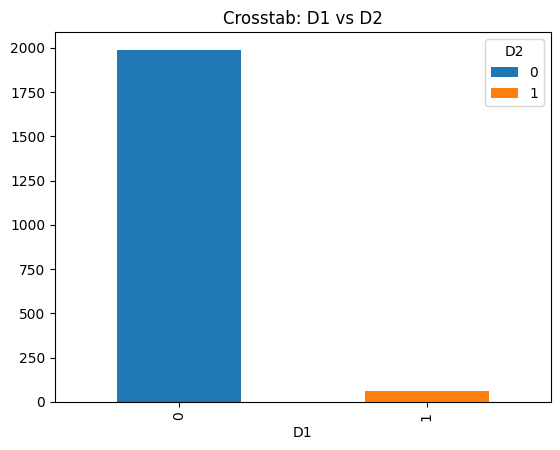

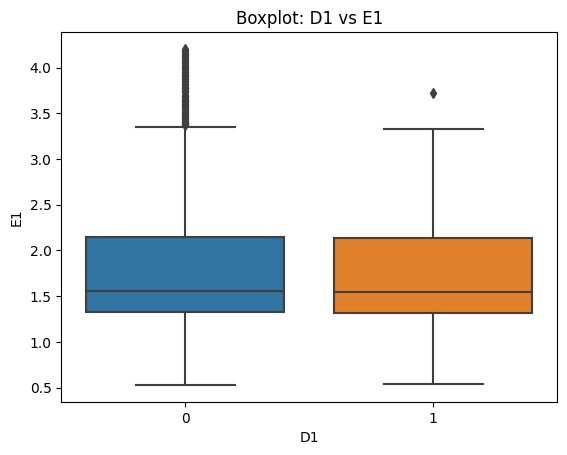

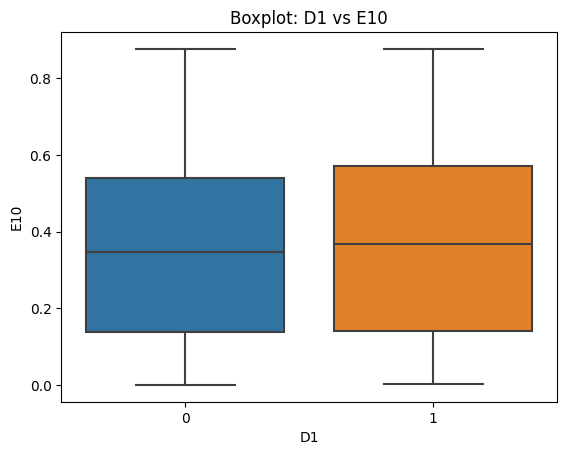

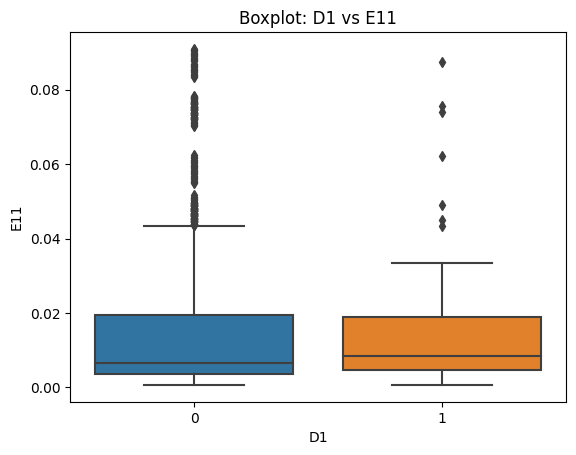

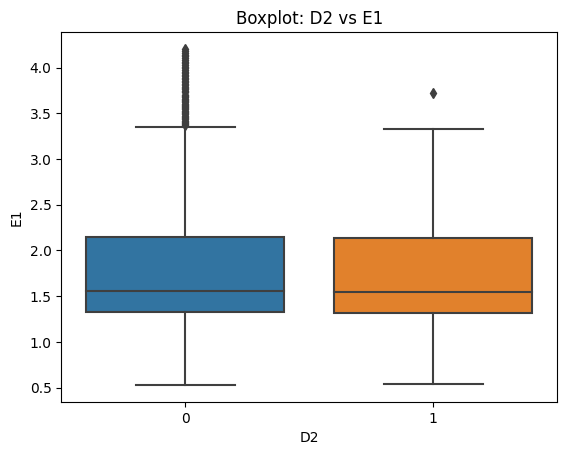

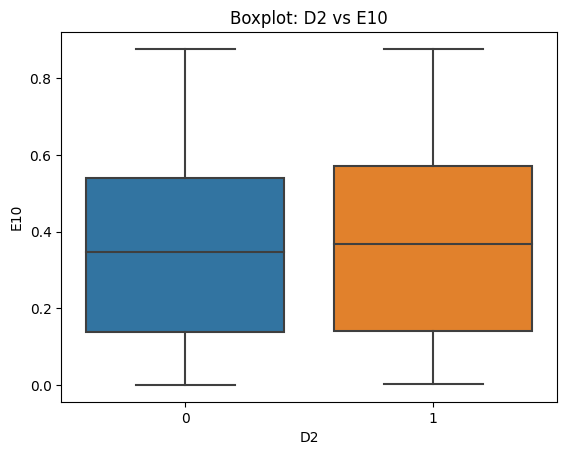

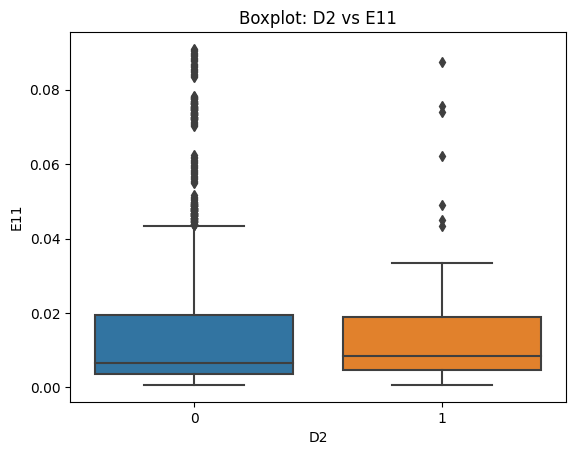

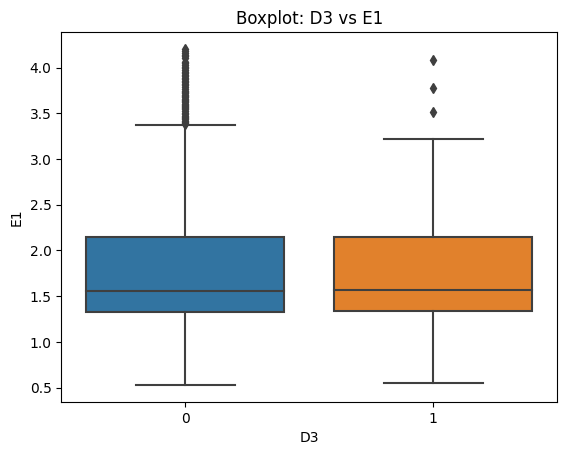

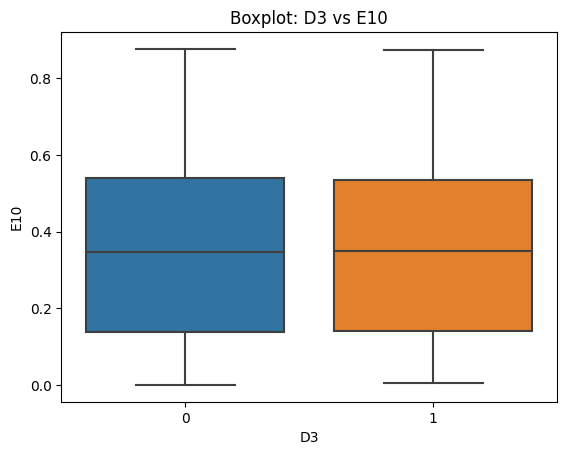

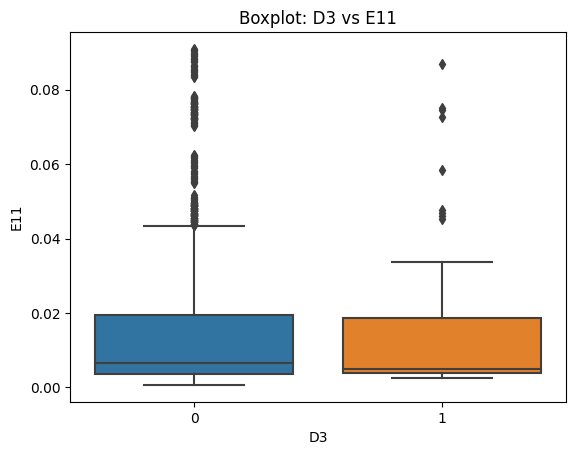

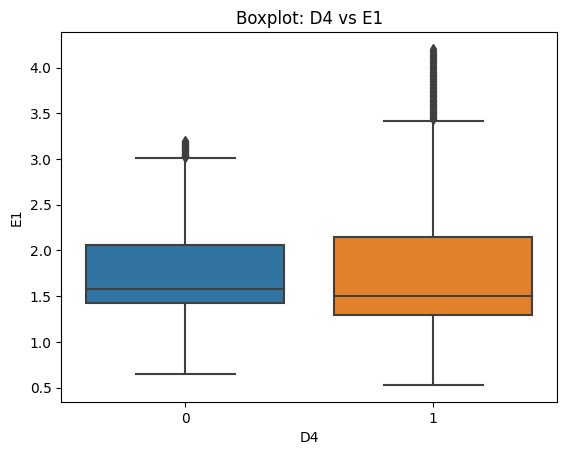

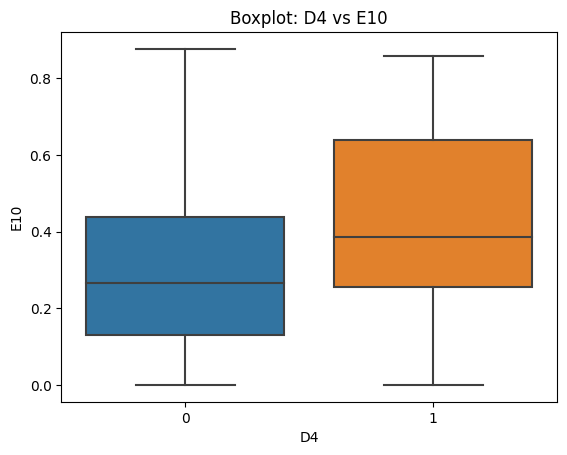

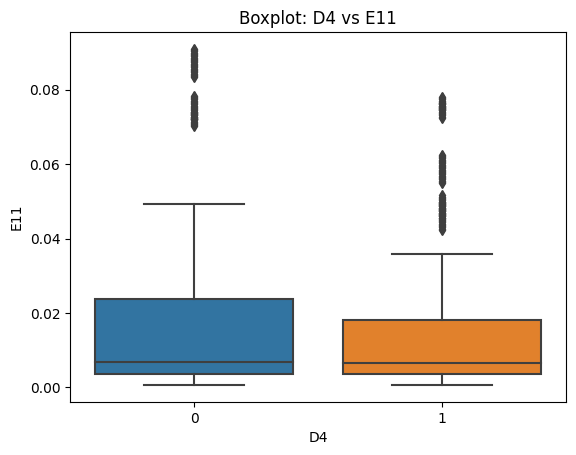

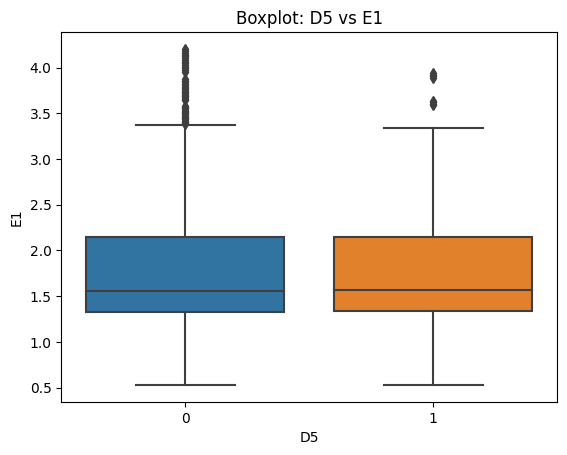

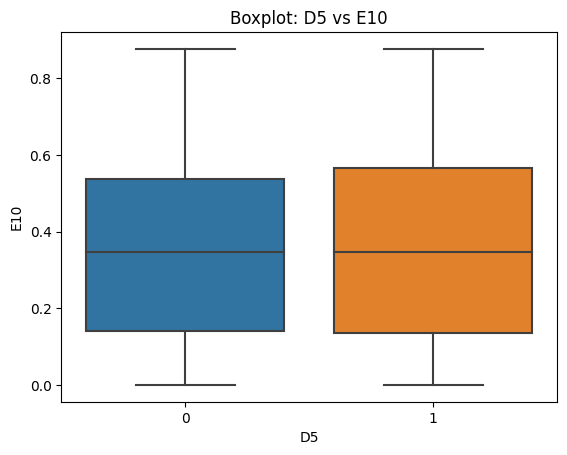

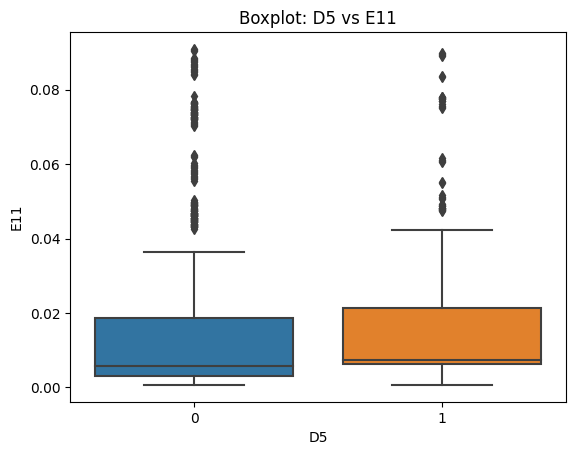

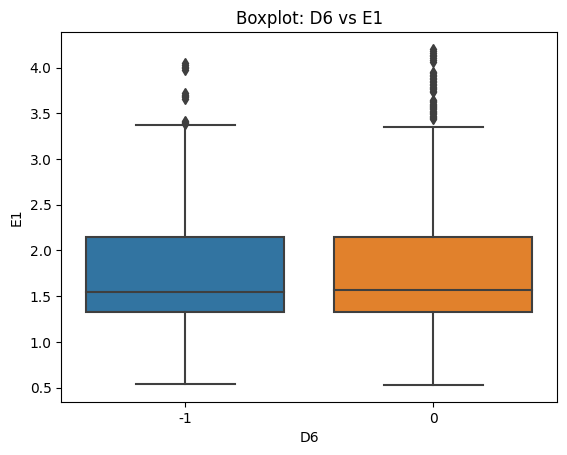

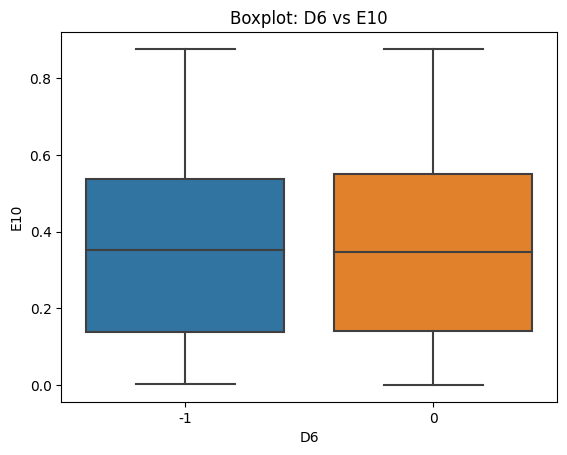

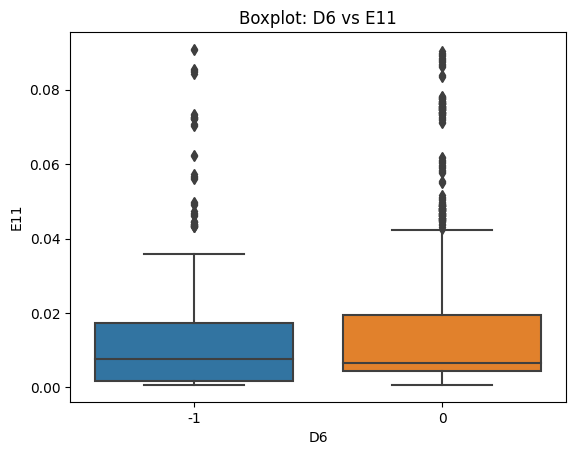

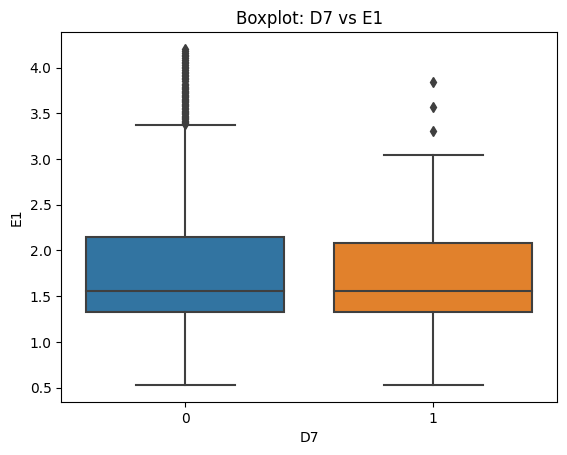

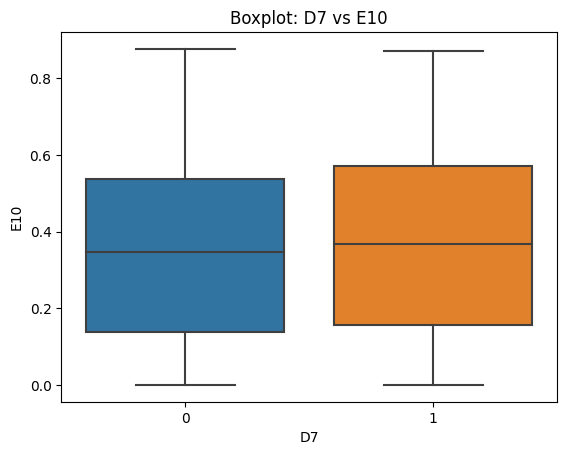

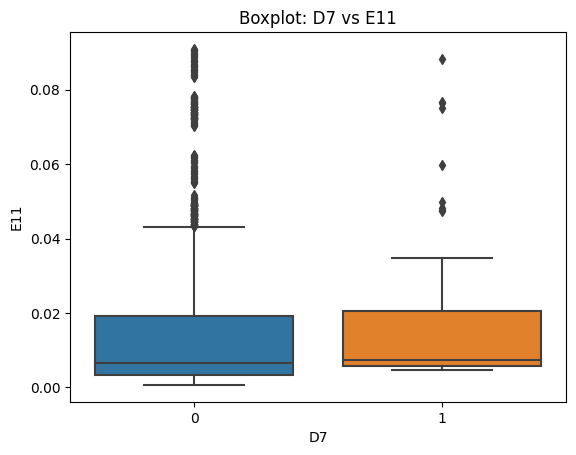

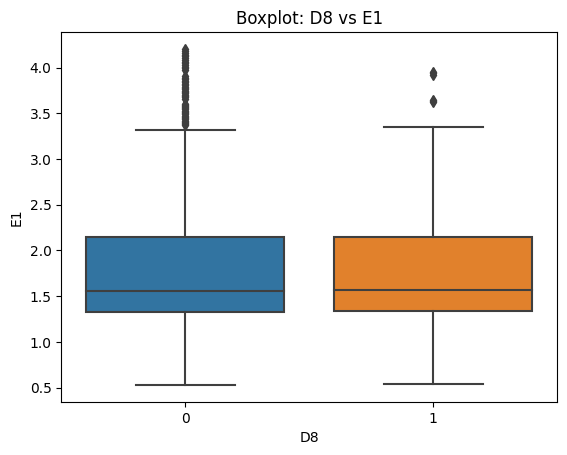

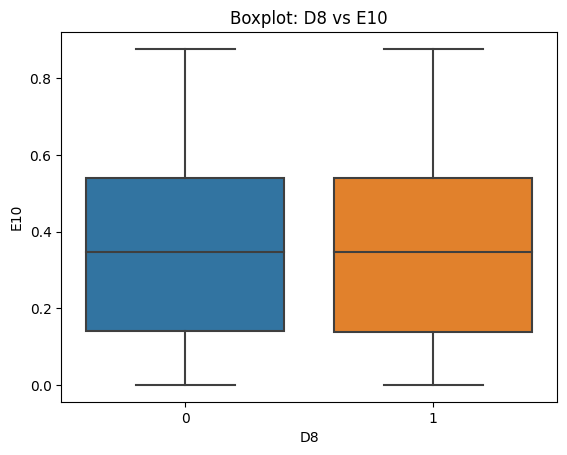

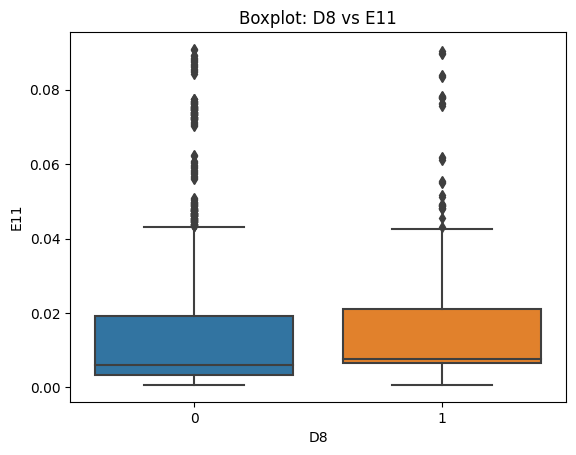

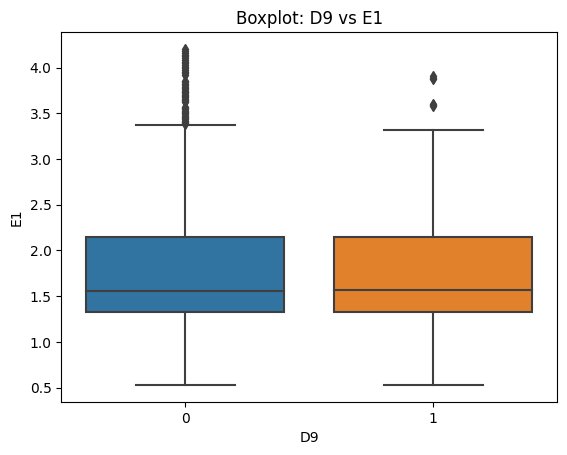

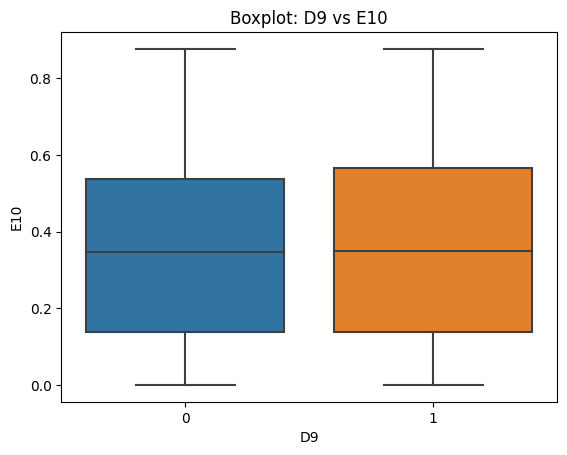

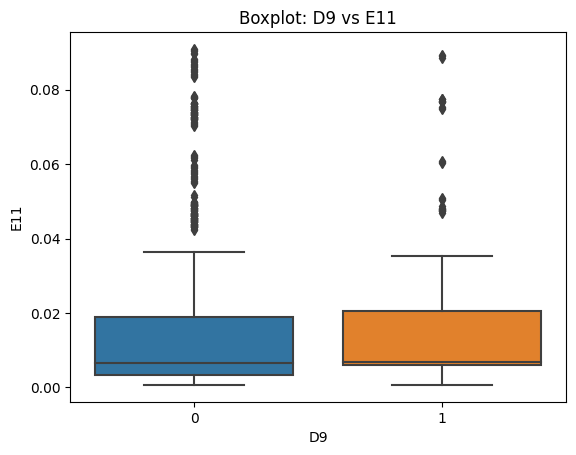

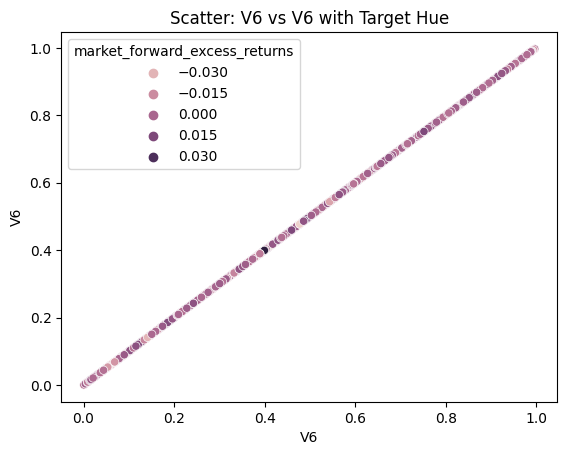

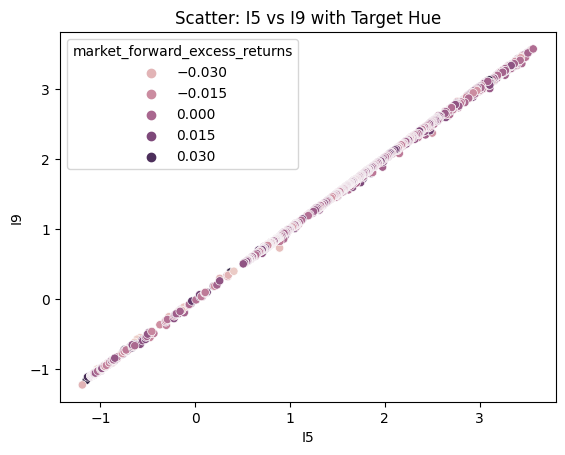

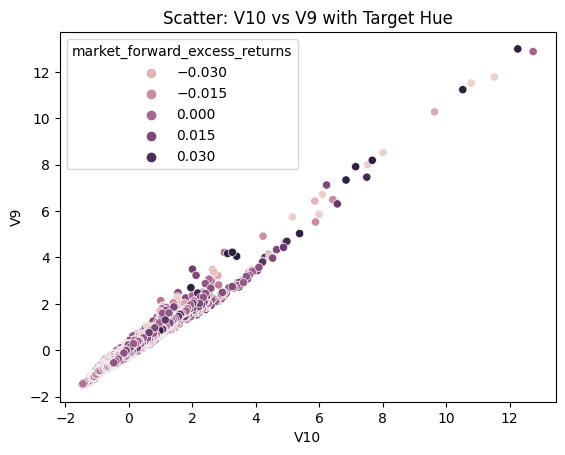

In [5]:
# Step 3: EDA (as before)
cat_cols = [col for col in df.columns if col.startswith('D') and col != 'date_id']
num_cols = [col for col in df.columns if col not in cat_cols + ['date_id', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']]
target = 'market_forward_excess_returns'

sns.pairplot(df[num_cols[:5] + [target]], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}})
plt.suptitle('Non-Linear Patterns in Numerical Features vs Target')
plt.show()

mi_scores = []  # Placeholder, since no sklearn; use corr for approx non-linear via abs
corr_matrix = df[num_cols + [target]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap for Numerical Features')
plt.show()

chi2_results = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        chi2, p, _, _ = chi2_contingency(pd.crosstab(df[cat_cols[i]], df[cat_cols[j]]))
        chi2_results.append((cat_cols[i], cat_cols[j], chi2, p))
chi2_df = pd.DataFrame(chi2_results, columns=['Cat1', 'Cat2', 'Chi2', 'p-value'])
print("Chi-Squared Tests:\n", chi2_df)

if len(cat_cols) >= 2:
    pd.crosstab(df[cat_cols[0]], df[cat_cols[1]]).plot(kind='bar', stacked=True)
    plt.title(f'Crosstab: {cat_cols[0]} vs {cat_cols[1]}')
    plt.show()

for cat in cat_cols:
    for num in num_cols[:3]:
        sns.boxplot(x=df[cat], y=df[num])
        plt.title(f'Boxplot: {cat} vs {num}')
        plt.show()

top_corr_pairs = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()[:3].index
for pair in top_corr_pairs:
    sns.scatterplot(x=df[pair[0]], y=df[pair[1]], hue=df[target])
    plt.title(f'Scatter: {pair[0]} vs {pair[1]} with Target Hue')
    plt.show()

In [6]:
# 1. Non-linear: E1
df['E1_sq'] = df['E1'] ** 2

# 2. Regime: E10
df['E10_low'] = (df['E10'] < 0.3).astype(float)
df['E10_high'] = (df['E10'] > 0.5).astype(float)

# 3. Momentum: E11
df['E11_winsor'] = df['E11'].clip(
    lower=df['E11'].quantile(0.01),
    upper=df['E11'].quantile(0.99)
)

# 4. Skew: E12
df['E12_log'] = np.log1p(df['E12'])

# 5. Drop noise
df.drop(['E13'], axis=1, inplace=True)

# 6. Interaction (E1 extreme + momentum)
df['E1_extreme_x_E11'] = df['E1_sq'] * df['E11_winsor']

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

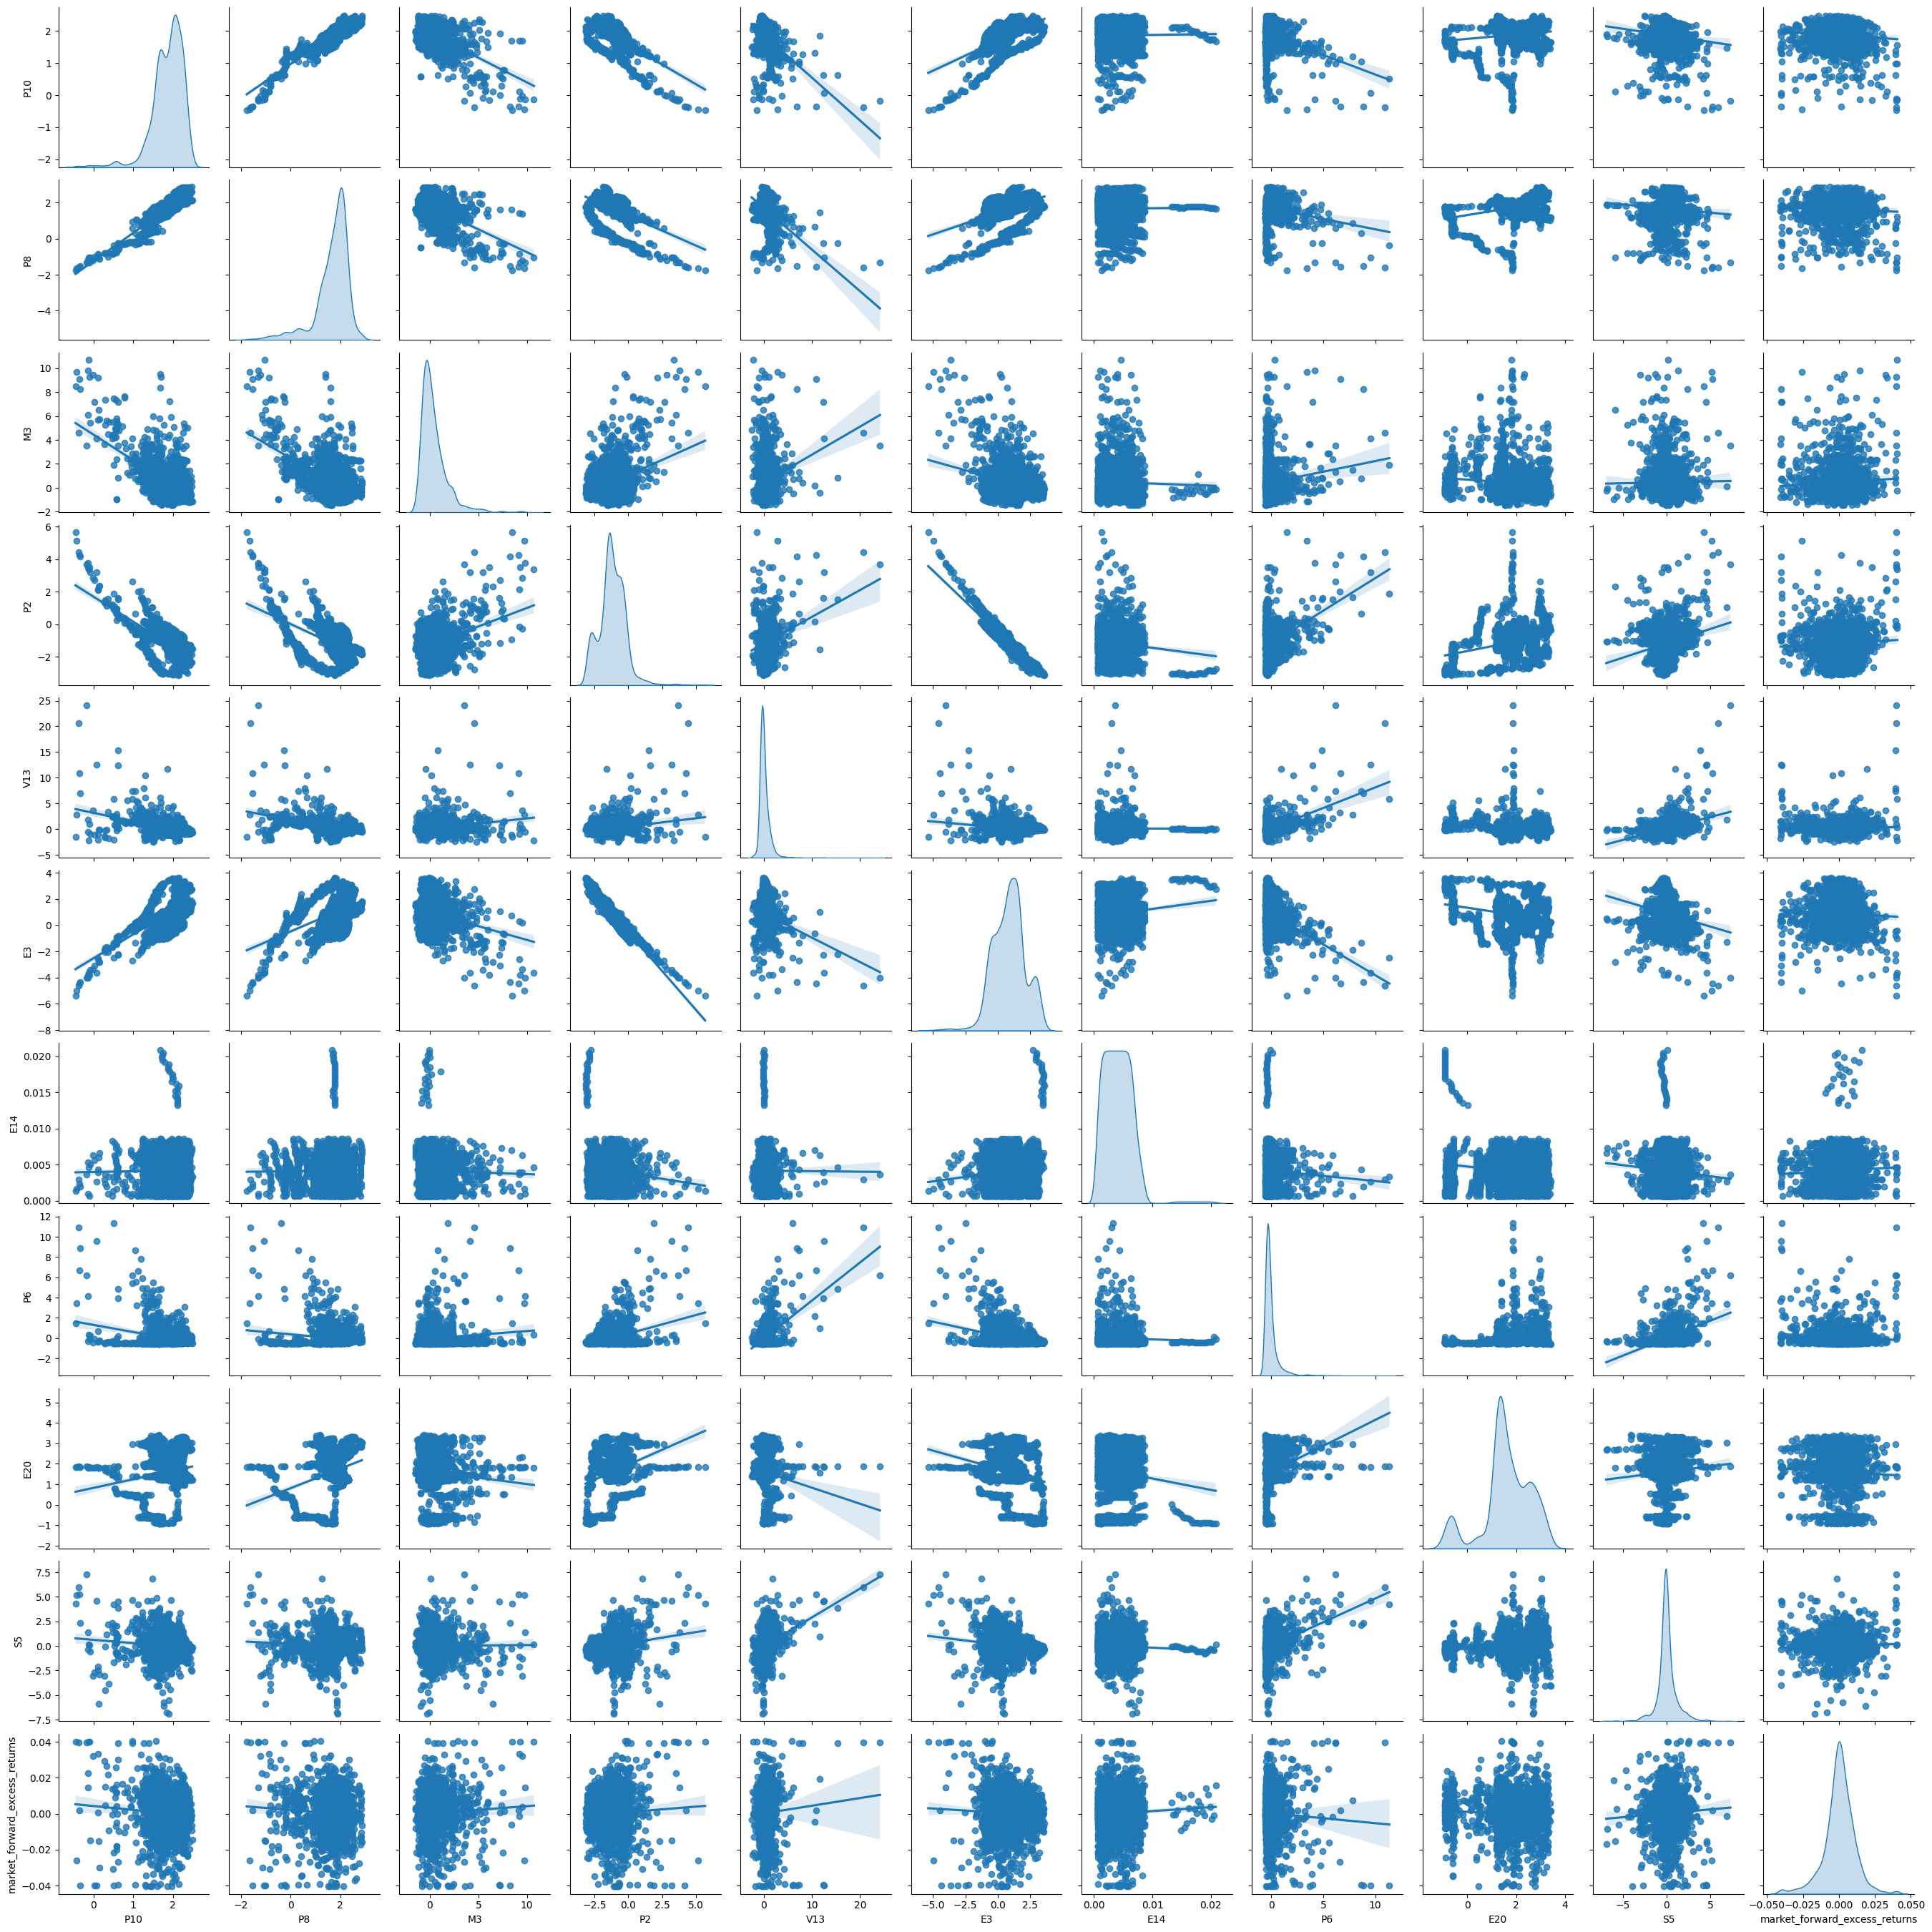

In [7]:
# Run pairplot on TOP 10 correlated features
top_features = corr_matrix[target].abs().sort_values(ascending=False).index[1:11]
sns.pairplot(df[list(top_features) + [target]], kind='reg', diag_kind='kde')
plt.show()

In [8]:
# ============================================================
# Full Corrected Training Code (with schema fix + adaptive scaling)
# ============================================================

import numpy as np
import polars as pl
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize, Bounds
from dataclasses import dataclass, asdict
import warnings
import kaggle_evaluation.default_inference_server
import os

warnings.filterwarnings("ignore")

# ============================================================
# Configs
# ============================================================
DATA_PATH = "/kaggle/input/hull-tactical-market-prediction/"
MIN_SIGNAL = 0.0
MAX_SIGNAL = 2.0
INITIAL_SIGNAL_MULTIPLIER = 400.0

# ============================================================
# Dataclasses
# ============================================================
@dataclass
class RetToSignalParameters:
    signal_multiplier: float
    min_signal: float = MIN_SIGNAL
    max_signal: float = MAX_SIGNAL


ret_signal_params = RetToSignalParameters(signal_multiplier=INITIAL_SIGNAL_MULTIPLIER)


# ============================================================
# Helper Functions
# ============================================================
def load_trainset() -> pl.DataFrame:
    return (
        pl.read_csv(DATA_PATH + "train.csv")
        .rename({"market_forward_excess_returns": "target"})
        .with_columns(pl.exclude("date_id").cast(pl.Float64, strict=False))
        .drop_nulls(subset=["target"])
    )


def load_testset() -> pl.DataFrame:
    return (
        pl.read_csv(DATA_PATH + "test.csv")
        .rename({"lagged_market_forward_excess_returns": "target"})
        .with_columns(pl.exclude("date_id").cast(pl.Float64, strict=False))
    )


def feature_engineering(df: pl.DataFrame) -> pl.DataFrame:
    """Add derived features from I and M blocks"""
    return (
        df.with_columns([
            (pl.col("I2") - pl.col("I1")).alias("U1"),
            (pl.col("M11") / ((pl.col("I2") + pl.col("I9") + pl.col("I7")) / 3)).alias("U2"),
        ])
        .with_columns(pl.all().fill_null(strategy="forward"))
        .drop_nulls()
    )


def adaptive_signal_scaling(ret_arr: np.ndarray, params: RetToSignalParameters) -> np.ndarray:
    """Auto-scale signals to avoid saturation to 2.0 or 0.0"""
    vol = np.std(ret_arr)
    adaptive_mult = params.signal_multiplier / (1 + 5 * vol)
    scaled = ret_arr * adaptive_mult + 1.0
    return np.clip(scaled, params.min_signal, params.max_signal)


# ============================================================
# Training + Optimization Pipeline
# ============================================================
def train_model():
    print("🔹 Loading data...")
    train = load_trainset()
    test = load_testset()

    # --- Align schema between train and test ---
    common_cols = [c for c in train.columns if c in test.columns]
    for c in common_cols:
        if train[c].dtype != test[c].dtype:
            train = train.with_columns(pl.col(c).cast(pl.Float64, strict=False))
            test = test.with_columns(pl.col(c).cast(pl.Float64, strict=False))

    df = pl.concat([train.select(common_cols), test.select(common_cols)], how="diagonal")
    df = feature_engineering(df)

    # --- Train/test split ---
    train = df.filter(pl.col("date_id").is_in(load_trainset()["date_id"]))
    test = df.filter(pl.col("date_id").is_in(load_testset()["date_id"]))

    FEATURES = [c for c in train.columns if c not in ["date_id", "target"]]

    X_train = train.select(FEATURES).to_numpy()
    y_train = train["target"].to_numpy()
    X_test = test.select(FEATURES).to_numpy()
    y_test = test["target"].to_numpy()

    # --- Scale ---
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # --- Ridge Regression ---
    print("🔹 Training Ridge Regression...")
    ridge_model = RidgeCV(alphas=np.logspace(-4, 2, 50), cv=5)
    ridge_model.fit(X_train, y_train)
    ridge_preds = ridge_model.predict(X_test)

    rmse = np.sqrt(np.mean((ridge_preds - y_test) ** 2))
    print(f"✅ Ridge RMSE: {rmse}")

    # --- Portfolio Optimization (Mean-CVaR) ---
    print("🔹 Optimizing portfolio...")
    mean_returns = np.mean(y_train)
    weights_init = np.ones(len(FEATURES)) / len(FEATURES)
    bounds = Bounds(0, 1)

    def objective(w):
        port_ret = np.dot(w, np.mean(X_train, axis=0))
        port_risk = np.std(np.dot(X_train, w))
        return -(port_ret / (port_risk + 1e-9))

    res = minimize(objective, weights_init, method="SLSQP", bounds=bounds)
    opt_weights = res.x / np.sum(res.x)

    # --- Fusion Classifier ---
    print("🔹 Running fusion model...")

    class FusionClassifier:
        def __init__(self, ridge_preds, opt_weights):
            self.ridge_preds = ridge_preds
            self.opt_weights = opt_weights

        def predict(self, X):
            n_samples = X.shape[0]
            ridge_component = self.ridge_preds[:n_samples]
            opt_component = np.dot(X[:, :len(self.opt_weights)], self.opt_weights)
            fusion = 0.6 * ridge_component + 0.4 * opt_component
            return fusion

    fusion = FusionClassifier(ridge_preds=ridge_preds, opt_weights=opt_weights)
    final_preds = fusion.predict(X_test)

    # --- Adaptive signal conversion ---
    signals = adaptive_signal_scaling(final_preds, ret_signal_params)
    print(f"✅ First 10 Fusion Signals: {signals[:10]}")

    return ridge_model, opt_weights, scaler, FEATURES


# ============================================================
# Inference Function for Kaggle Evaluation Server
# ============================================================
ridge_model, opt_weights, scaler, FEATURES = train_model()


def predict(test: pl.DataFrame) -> float:
    test = test.rename({"lagged_market_forward_excess_returns": "target"})
    df = feature_engineering(test)
    X = df.select(FEATURES).to_numpy()
    X_scaled = scaler.transform(X)

    # Reuse ridge + optimization fusion
    ridge_pred = ridge_model.predict(X_scaled)[0]
    opt_component = np.dot(X_scaled[:, :len(opt_weights)], opt_weights)[0]
    combined_pred = 0.6 * ridge_pred + 0.4 * opt_component

    signal = adaptive_signal_scaling(np.array([combined_pred]), ret_signal_params)[0]
    return float(signal)


# ============================================================
# Launch Kaggle Inference Server
# ============================================================
inference_server = kaggle_evaluation.default_inference_server.DefaultInferenceServer(predict)

if os.getenv("KAGGLE_IS_COMPETITION_RERUN"):
    inference_server.serve()
else:
    inference_server.run_local_gateway((DATA_PATH,))


🔹 Loading data...
🔹 Training Ridge Regression...
✅ Ridge RMSE: 0.004967169357958144
🔹 Optimizing portfolio...
🔹 Running fusion model...
✅ First 10 Fusion Signals: [2. 2. 0. 2. 2. 0. 2. 2. 0. 0.]
